# DELTA1 Strategy v2.7 — corrected research audit

This notebook is the executed walkthrough for the single strategy implemented in
`strategy.py`: a 61-market futures portfolio combining 12-month sign trend and
basis momentum. It uses the audited v2.7 engine, including next-session execution,
integer contracts, a self-financing USD NAV ledger, capacity-limited rebalances,
and approximate two-leg roll costs.

**Verdict.** The strategy is credible as historical research, but it is not ready
for real-money deployment. Under the canonical next-close ledger, the selected
1990–2004 CAGR is about 24.5%, while the naive daily Sharpe is about 1.985: the
requested 20% CAGR / 2.0 Sharpe pair is **not** met. Monthly and
autocorrelation-robust estimates are lower, uncertainty is wide, all available
periods have been reused, and the history ends in 2014.

## 1. Reproducible setup

The notebook imports the canonical implementation; it does not duplicate strategy
formulas. Set `DELTA1_DATA_DIR` to relocate the supplied dataset. When the variable
is absent, the repository-local `Round1AllData/Quant Researcher/Delta1` directory is
used.

In [1]:
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from strategy import (
    REPORTING_WINDOWS,
    STRATEGY_NAME,
    StrategyConfig,
    monthly_block_bootstrap_intervals,
    performance_metrics,
    run_backtest,
    run_pipeline,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

env_data_dir = os.environ.get("DELTA1_DATA_DIR")
candidates = []
if env_data_dir:
    candidates.append(Path(env_data_dir).expanduser())
candidates.append(Path("Round1AllData/Quant Researcher/Delta1"))

data_dir = next((path.resolve() for path in candidates if path.is_dir()), None)
if data_dir is None:
    searched = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(
        "DELTA1 dataset not found. Set DELTA1_DATA_DIR. Searched:\n" + searched
    )

config = StrategyConfig(data_dir=data_dir, output_dir=Path("outputs"))
print(f"Strategy: {STRATEGY_NAME}")
print(f"Data:     {data_dir}")
print(f"Engine:   next-session {config.execution_timing}, "
      f"${config.initial_capital:,.0f} initial NAV, integer contracts")
print(f"Launch:   {config.launch_date}, zero positions; earlier data are warm-up only")

Strategy: Audited Global TSMOM + Basis Momentum (61 markets)
Data:     /Users/ian/Projects/delta1_strategy/Round1AllData/Quant Researcher/Delta1
Engine:   next-session next_close, $1,000,000 initial NAV, integer contracts
Launch:   1990-01-01, zero positions; earlier data are warm-up only


## 2. Canonical v2.7 run

The investable ledger launches on **1990-01-01 with $1 million and zero positions**.
Pre-1990 observations may warm forecasts and risk estimates, but they contribute no
P&L and cannot seed holdings or the no-trade state. A signal calculated from a
month-end close becomes a pending order whose contract quantity is frozen using NAV
on that decision date. In the canonical case it fills at that market's next raw,
positive-volume session close. Existing contracts receive that session's full
close-to-close P&L; newly executed contracts begin earning P&L only on the following
bar. This conservative convention is identifiable from date-only global input bars.
Costs are half a tick plus $2.50 for every one-way contract leg, including detected
continuous-contract rolls.

In [2]:
result, metrics = run_pipeline(config)

metric_columns = [
    "Window",
    "CAGR",
    "Annualized volatility",
    "Naive daily Sharpe (sqrt252, rf=0)",
    "Monthly Sharpe (rf=0)",
    "HAC Sharpe (21 lags, rf=0)",
    "Max drawdown",
    "Annual cost drag",
    "Both point-estimate targets met",
]
metric_view = metrics[metric_columns].set_index("Window")
display(
    metric_view.style.format(
        {
            "CAGR": "{:.2%}",
            "Annualized volatility": "{:.2%}",
            "Naive daily Sharpe (sqrt252, rf=0)": "{:.3f}",
            "Monthly Sharpe (rf=0)": "{:.3f}",
            "HAC Sharpe (21 lags, rf=0)": "{:.3f}",
            "Max drawdown": "{:.2%}",
            "Annual cost drag": "{:.2%}",
        }
    )
)

launch_timestamp = pd.Timestamp(config.launch_date)
pre_launch = result.daily.index < launch_timestamp
launch_audit = pd.Series(
    {
        "Configured launch date": config.launch_date,
        "NAV at launch (USD)": result.daily.loc[launch_timestamp, "nav"],
        "Contracts held at launch": result.positions.loc[launch_timestamp].abs().sum(),
        "Pre-launch NAV always equals initial capital": bool(
            np.allclose(result.daily.loc[pre_launch, "nav"], config.initial_capital)
        ),
        "Pre-launch positions always zero": bool(
            result.positions.loc[pre_launch].eq(0).all().all()
        ),
    },
    name="Launch-boundary audit",
)
display(launch_audit.to_frame())

,CAGR,Annualized volatility,"Naive daily Sharpe (sqrt252, rf=0)",Monthly Sharpe (rf=0),"HAC Sharpe (21 lags, rf=0)",Max drawdown,Annual cost drag,Both point-estimate targets met
Window,,,,,,,,
1990-1997 selected subperiod A,23.59%,11.06%,1.907,1.660,1.642,-14.66%,1.26%,False
1998-2004 selected subperiod B,25.59%,10.89%,2.075,2.134,1.988,-10.21%,0.94%,True
1990-2004 selected window,24.52%,10.98%,1.985,1.855,1.784,-14.66%,1.11%,False
2005-2014 reused later diagnostic,14.84%,11.22%,1.248,1.248,1.202,-16.41%,0.65%,False
1990-2014 full post-launch history,20.56%,11.08%,1.686,1.615,1.551,-16.41%,0.93%,False


,Launch-boundary audit
Configured launch date,1990-01-01
NAV at launch (USD),1000000.0
Contracts held at launch,0.0
Pre-launch NAV always equals initial capital,True
Pre-launch positions always zero,True


The daily Sharpe is \(\sqrt{252}\,\bar r / s_r\), with a zero risk-free
rate. It is the user's requested convention, but it is not invariant to the
calendar construction and it ignores serial correlation. The monthly and 21-lag
HAC estimates are therefore reported beside it. The canonical selected-window
estimate is about **1.985**, below 2.000 even before accounting for strategy
selection. Passing or narrowly missing a point-estimate threshold does not validate
a durable expected return.

## 3. Sampling uncertainty: circular block bootstrap

This deterministic bootstrap resamples six-month blocks of the 1990–2004 monthly
return series, preserving some serial dependence. It is an uncertainty diagnostic,
**not** a selection adjustment: the strategy specification and test period were
chosen after inspecting the data.

In [3]:
selected_start, selected_end = REPORTING_WINDOWS["1990-2004 selected window"]
selected_metrics = performance_metrics(result, selected_start, selected_end)
bootstrap_ci = monthly_block_bootstrap_intervals(
    result,
    selected_start,
    selected_end,
    samples=20_000,
    block_months=6,
    seed=20_260_803,
)

uncertainty = pd.DataFrame(
    {
        "Point estimate": [
            selected_metrics["Monthly Sharpe (rf=0)"],
            selected_metrics["CAGR"],
        ],
        "95% lower": [
            bootstrap_ci["Monthly Sharpe 95% lower"],
            bootstrap_ci["CAGR 95% lower"],
        ],
        "95% upper": [
            bootstrap_ci["Monthly Sharpe 95% upper"],
            bootstrap_ci["CAGR 95% upper"],
        ],
    },
    index=["Monthly Sharpe", "CAGR"],
)
uncertainty_display = uncertainty.copy().astype(object)
for column in uncertainty_display:
    uncertainty_display.loc["Monthly Sharpe", column] = f"{uncertainty.loc['Monthly Sharpe', column]:.3f}"
    uncertainty_display.loc["CAGR", column] = f"{uncertainty.loc['CAGR', column]:.2%}"
display(uncertainty_display)
print(
    f"Bootstrap: {int(bootstrap_ci['Bootstrap samples']):,} samples, "
    f"{int(bootstrap_ci['Block months'])}-month circular blocks; "
    f"selection adjusted = {bootstrap_ci['Selection adjusted']}"
)

,Point estimate,95% lower,95% upper
Monthly Sharpe,1.855,1.374,2.400
CAGR,24.52%,17.62%,31.70%


Bootstrap: 20,000 samples, 6-month circular blocks; selection adjusted = False


## 4. Execution and cost sensitivity

Three like-for-like selected-window cases are recomputed below:

- **Canonical next close:** half-tick spread proxy plus $2.50 commission; a new
  target cannot earn any part of its execution session.
- **Unverified next open:** an optimistic diagnostic only. The files provide
  date-only bars across global markets, without the timestamps, time zones, or
  session definitions needed to prove that each `Open` follows the decision and is
  executable on the modeled date.
- **One-tick cost stress:** canonical next-close execution with a full tick of
  one-way spread cost plus the same $2.50 commission.

These are model sensitivities, not estimates of market impact or guaranteed fills.
The unverified next-open row must not be used to claim a 2.0 Sharpe.

,CAGR,Naive daily Sharpe,Monthly Sharpe,HAC Sharpe,Max drawdown,Annual cost drag
Case,,,,,,
Canonical next close,24.52%,1.985,1.855,1.784,-14.66%,1.11%
Unverified next open,25.63%,2.052,1.926,1.875,-11.04%,1.11%
One-tick next-close cost stress,23.60%,1.917,1.793,1.720,-14.88%,1.85%


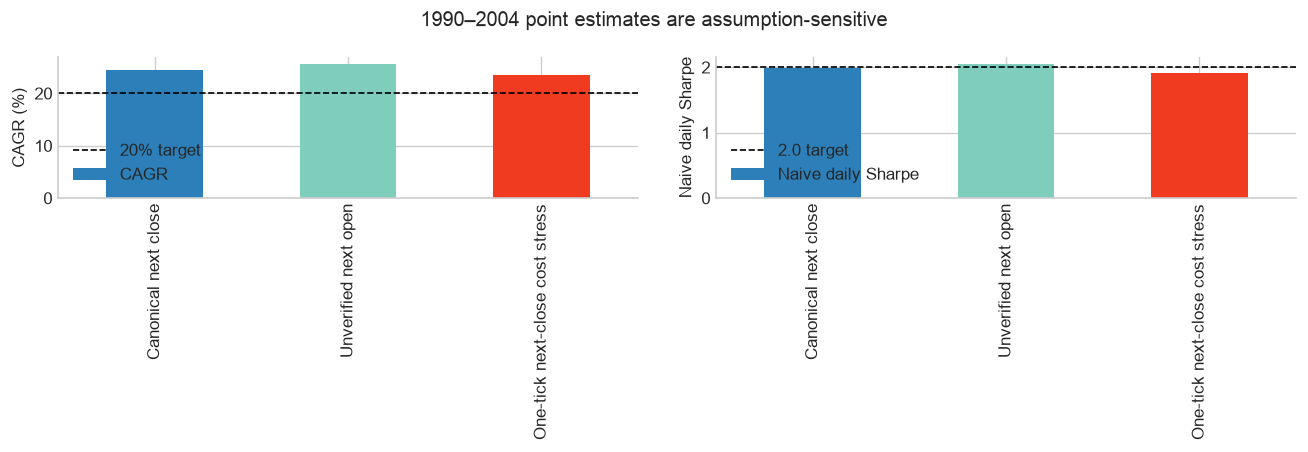

In [4]:
variant_configs = {
    "Canonical next close": config,
    "Unverified next open": replace(config, execution_timing="next_open"),
    "One-tick next-close cost stress": replace(config, half_spread_ticks=1.0),
}
variant_results = {"Canonical next close": result}
sensitivity_rows = []

for label, variant_config in variant_configs.items():
    variant_result = variant_results.get(label)
    if variant_result is None:
        variant_result = run_backtest(variant_config)
        variant_results[label] = variant_result
    row = performance_metrics(variant_result, selected_start, selected_end)
    sensitivity_rows.append(
        {
            "Case": label,
            "CAGR": row["CAGR"],
            "Naive daily Sharpe": row["Naive daily Sharpe (sqrt252, rf=0)"],
            "Monthly Sharpe": row["Monthly Sharpe (rf=0)"],
            "HAC Sharpe": row["HAC Sharpe (21 lags, rf=0)"],
            "Max drawdown": row["Max drawdown"],
            "Annual cost drag": row["Annual cost drag"],
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows).set_index("Case")
display(
    sensitivity.style.format(
        {
            "CAGR": "{:.2%}",
            "Naive daily Sharpe": "{:.3f}",
            "Monthly Sharpe": "{:.3f}",
            "HAC Sharpe": "{:.3f}",
            "Max drawdown": "{:.2%}",
            "Annual cost drag": "{:.2%}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sensitivity["CAGR"].mul(100).plot.bar(ax=axes[0], color=["#2C7FB8", "#7FCDBB", "#F03B20"])
axes[0].axhline(20, color="black", linestyle="--", linewidth=1, label="20% target")
axes[0].set_ylabel("CAGR (%)")
axes[0].set_xlabel("")
axes[0].legend(frameon=False)
sensitivity["Naive daily Sharpe"].plot.bar(
    ax=axes[1], color=["#2C7FB8", "#7FCDBB", "#F03B20"]
)
axes[1].axhline(2.0, color="black", linestyle="--", linewidth=1, label="2.0 target")
axes[1].set_ylabel("Naive daily Sharpe")
axes[1].set_xlabel("")
axes[1].legend(frameon=False)
fig.suptitle("1990–2004 point estimates are assumption-sensitive")
fig.tight_layout()
plt.show()

## 5. NAV and drawdown

The plot uses the actual integer-contract, cost-deducted NAV from the explicit
1990 launch through the end of the supplied data in 2014. The shaded area is the
retrospectively selected 1990–2004 interval; 2005–2014 was also inspected in prior
research and is not an untouched out-of-sample test.

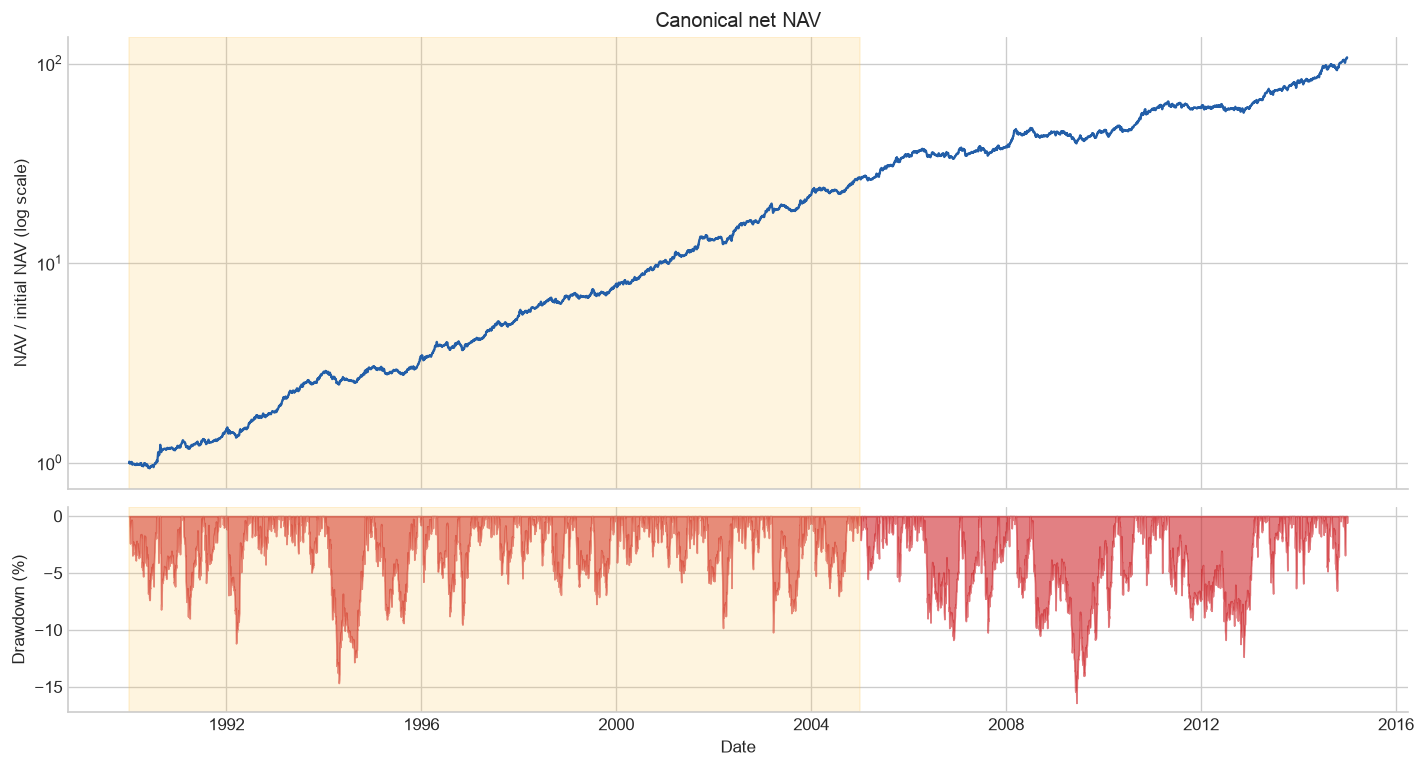

In [5]:
launch_timestamp = pd.Timestamp(config.launch_date)
post_launch_equity = result.daily.loc[launch_timestamp:, "equity"]
post_launch_peak = np.maximum.accumulate(
    np.r_[1.0, post_launch_equity.to_numpy()]
)[1:]
post_launch_drawdown = pd.Series(
    post_launch_equity.to_numpy() / post_launch_peak - 1,
    index=post_launch_equity.index,
    name="drawdown",
)
path = result.daily.loc[launch_timestamp:"2014-12-31"].copy()
path["drawdown"] = post_launch_drawdown.reindex(path.index)

fig, axes = plt.subplots(
    2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]}
)
axes[0].plot(path.index, path["equity"], color="#225EA8", linewidth=1.35)
axes[0].set_yscale("log")
axes[0].set_ylabel("NAV / initial NAV (log scale)")
axes[0].set_title("Canonical net NAV")
axes[1].fill_between(path.index, path["drawdown"] * 100, 0, color="#CB181D", alpha=0.55)
axes[1].set_ylabel("Drawdown (%)")
for axis in axes:
    axis.axvspan(pd.Timestamp(selected_start), pd.Timestamp(selected_end), color="#FEC44F", alpha=0.18)
axes[1].set_xlabel("Date")
fig.tight_layout()
plt.show()

## 6. Economic exposure and margin diagnostic

`risk_scalar` is a volatility-target multiplier, not leverage. Economic exposure is
reported separately as gross contract notional divided by current NAV. Margin uses
the catalogue's single static margin snapshot converted to USD; it is useful for
scale intuition, but it is not a historical margin simulation and cannot reproduce
exchange margin calls.

,Average,95th percentile,Peak
Gross notional / NAV,4.75,7.37,8.65
Static margin / NAV,0.33,0.52,0.73
Risk scalar,0.82,1.29,1.46
Markets held,37.83,52.00,57.00


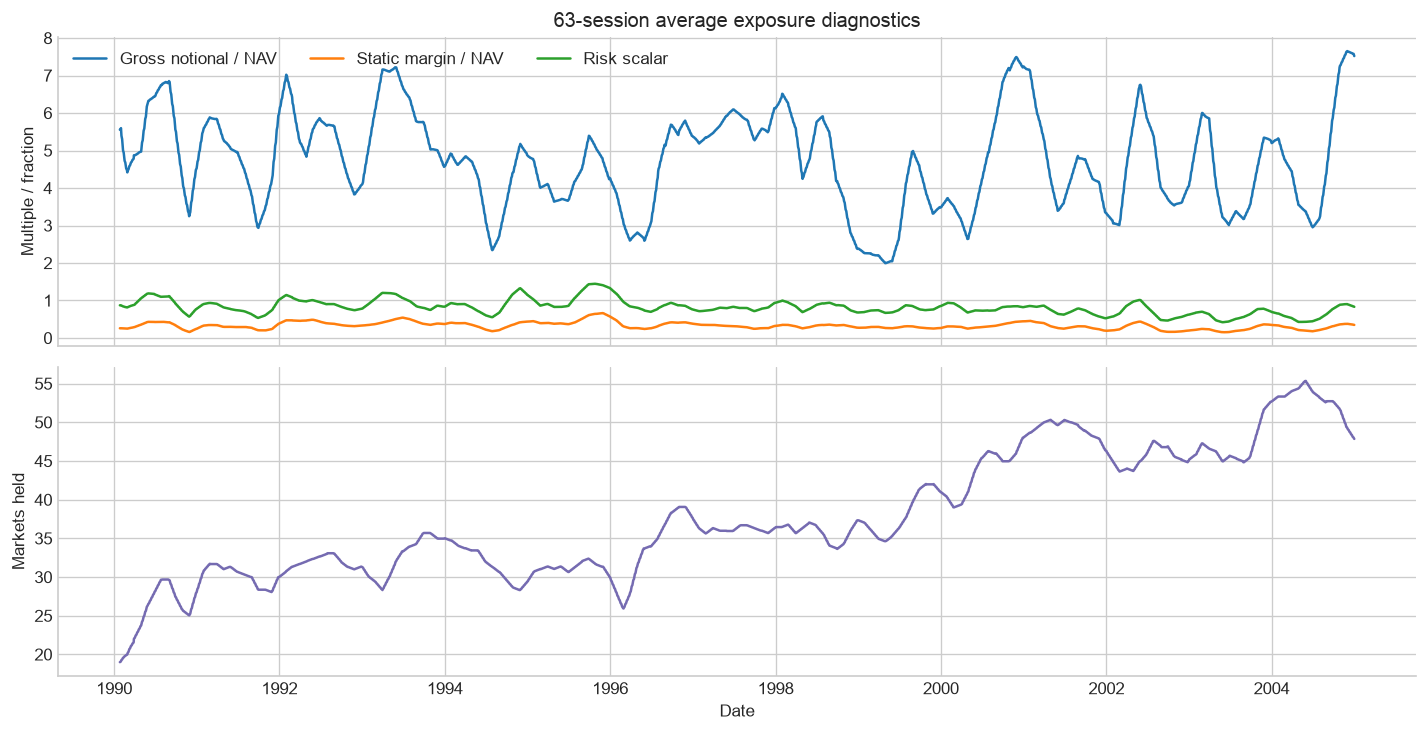

In [6]:
selected_daily = result.daily.loc[selected_start:selected_end].copy()
exposure_summary = pd.DataFrame(
    {
        "Average": [
            selected_daily["gross_notional_multiple"].mean(),
            selected_daily["static_margin_fraction"].mean(),
            selected_daily["risk_scalar"].mean(),
            selected_daily["active_markets"].mean(),
        ],
        "95th percentile": [
            selected_daily["gross_notional_multiple"].quantile(0.95),
            selected_daily["static_margin_fraction"].quantile(0.95),
            selected_daily["risk_scalar"].quantile(0.95),
            selected_daily["active_markets"].quantile(0.95),
        ],
        "Peak": [
            selected_daily["gross_notional_multiple"].max(),
            selected_daily["static_margin_fraction"].max(),
            selected_daily["risk_scalar"].max(),
            selected_daily["active_markets"].max(),
        ],
    },
    index=[
        "Gross notional / NAV",
        "Static margin / NAV",
        "Risk scalar",
        "Markets held",
    ],
)
display(exposure_summary.style.format("{:.2f}"))

quarterly = selected_daily[
    ["gross_notional_multiple", "static_margin_fraction", "risk_scalar", "active_markets"]
].rolling(63, min_periods=20).mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True)
axes[0].plot(quarterly.index, quarterly["gross_notional_multiple"], label="Gross notional / NAV")
axes[0].plot(quarterly.index, quarterly["static_margin_fraction"], label="Static margin / NAV")
axes[0].plot(quarterly.index, quarterly["risk_scalar"], label="Risk scalar")
axes[0].set_ylabel("Multiple / fraction")
axes[0].legend(ncol=3, frameon=False)
axes[0].set_title("63-session average exposure diagnostics")
axes[1].plot(quarterly.index, quarterly["active_markets"], color="#756BB1")
axes[1].set_ylabel("Markets held")
axes[1].set_xlabel("Date")
fig.tight_layout()
plt.show()

## 7. Roll, turnover, and execution diagnostics

Vendor delivery-month changes are filtered to quarantine isolated A/B/A spikes and
backward label anomalies. On an accepted roll date, the cost ledger charges the
legs needed to exit the old expiry and enter the new one. This corrects the earlier
omission of roll turnover, but the P&L series is still continuous/back-adjusted, so
neither leg is tied to an observed serial-contract fill.

,1990–2004
Vendor roll flags (all markets),"4,038.000"
Executed roll flags (all markets),"3,286.000"
Days with incremental held-book roll turnover,"1,389.000"
Rebalance contract turnover,"50,211.000"
Incremental roll contract turnover,"99,010.000"
Total charged contract turnover,"149,221.000"
Incremental roll share of charged turnover,0.664
Transaction costs (USD),"1,080,387.380"
Peak charged turnover / reported volume,2.000
Peak pending markets,53.000


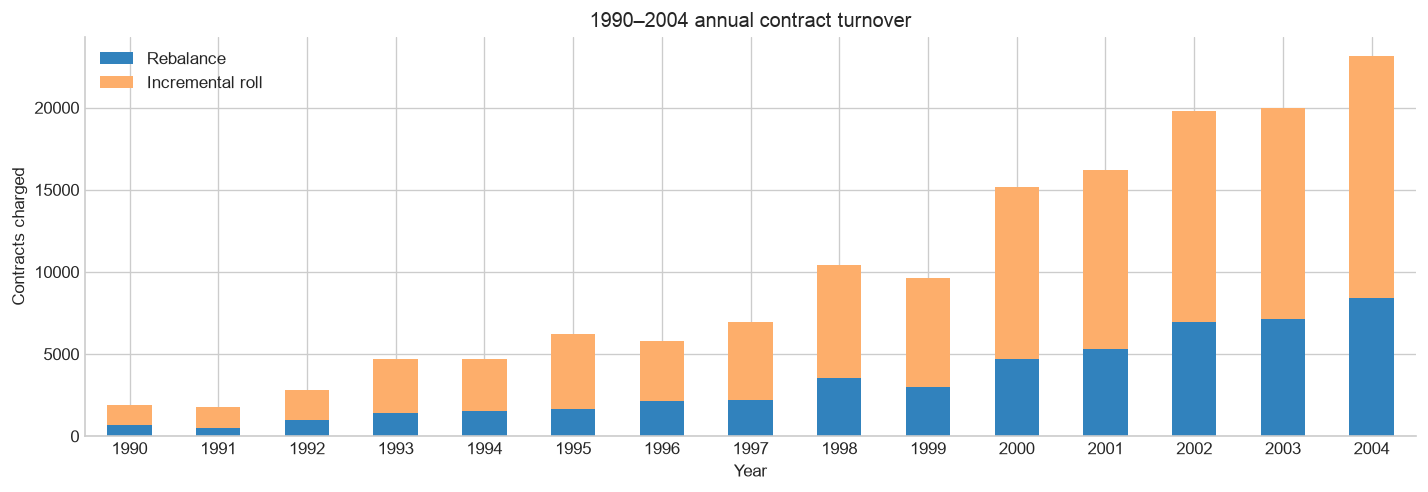

In [7]:
vendor_roll_flags = int(result.roll_events.loc[selected_start:selected_end].sum().sum())
executed_roll_flags = int(result.executed_rolls.loc[selected_start:selected_end].sum().sum())
charged_roll_days = int((selected_daily["roll_contract_turnover_increment"] > 0).sum())
rebalance_contracts = selected_daily["rebalance_contract_turnover"].sum()
incremental_roll_contracts = selected_daily["roll_contract_turnover_increment"].sum()
total_contracts = selected_daily["total_contract_turnover"].sum()

execution_summary = pd.Series(
    {
        "Vendor roll flags (all markets)": vendor_roll_flags,
        "Executed roll flags (all markets)": executed_roll_flags,
        "Days with incremental held-book roll turnover": charged_roll_days,
        "Rebalance contract turnover": rebalance_contracts,
        "Incremental roll contract turnover": incremental_roll_contracts,
        "Total charged contract turnover": total_contracts,
        "Incremental roll share of charged turnover": (
            incremental_roll_contracts / total_contracts if total_contracts else np.nan
        ),
        "Transaction costs (USD)": selected_daily["transaction_cost_usd"].sum(),
        "Peak charged turnover / reported volume": selected_daily["max_order_participation"].max(),
        "Peak pending markets": selected_daily["pending_markets"].max(),
    },
    name="1990–2004",
)
display(execution_summary.to_frame().style.format("{:,.3f}"))

annual_turnover = selected_daily[
    ["rebalance_contract_turnover", "roll_contract_turnover_increment"]
].resample("YE").sum()
annual_turnover.columns = ["Rebalance", "Incremental roll"]
ax = annual_turnover.plot.bar(stacked=True, figsize=(12, 4.2), color=["#3182BD", "#FDAE6B"])
ax.set_xticklabels(annual_turnover.index.year, rotation=0)
ax.set_ylabel("Contracts charged")
ax.set_xlabel("Year")
ax.set_title("1990–2004 annual contract turnover")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The 5% participation cap applies to **rebalance** orders using lagged median volume.
Detected expiry rolls are an operational necessity and are not capacity-limited in
this continuous-contract approximation. Therefore a high charged-turnover/volume
ratio is a warning that serial-contract liquidity and a real roll schedule are
required—not evidence that the displayed roll could actually be executed.

## 8. What is corrected, and what remains missing

Corrected in v2.7:

- the investable ledger launches at $1 million with zero positions on 1990-01-01;
  pre-launch observations warm signals and risk estimates only;
- the no-trade state resets at launch, and each pending order freezes its contract
  quantity using decision-date NAV rather than later execution-date NAV;
- no month-end close look-ahead: targets fill only on a later observed session;
- canonical next-close orders earn no P&L before their execution close; an
  alternative next-open split is retained only as an unverified sensitivity;
- actual integer contracts and dollar NAV replace free daily fractional rescaling;
- transaction costs include strategy trades and approximate two-leg roll turnover;
- USD point values, gross notional, static margin, capacity, pending orders, and
  missing held valuation inputs are explicitly handled;
- the volatility-target multiplier is labeled `risk_scalar`, while economic gross
  notional is reported independently;
- CAGR includes the first return interval and Sortino uses downside RMS.

Remaining production blockers:

1. **No serial-contract backtest.** Continuous back-adjusted prices cannot specify
   the expiry, roll spread, first-notice constraint, or executable roll fills.
2. **Static contract metadata.** Point values and catalogue margins are not dated;
   historical exchange/clearing fees, margin changes, portfolio offsets, collateral
   yield, and funding liquidity are absent.
3. **Simplified execution.** Half-tick costs and reported volume do not model bid/ask
   states, market impact, limit moves, venue hours, queueing, or broker rejects.
4. **Point-in-time bias.** The current 61-market universe is applied backward and is
   vulnerable to survivorship and availability bias.
5. **Selection and stale validation.** The 1990–2004 period was used to choose the
   strategy; other periods were also inspected; no multiple-testing correction is
   possible from the retained point-metric ledgers; and the supplied data end in
   2014.

**Deployment decision:** do not allocate capital from this backtest alone. Obtain
point-in-time serial contracts and metadata, reconstruct expiry-specific orders and
cash/margin, calibrate costs to intended order size, test genuinely unseen post-2014
data, and complete forward paper trading and operational risk controls first.

## 9. Reproduction note

The canonical repository artifacts are produced by running `strategy.py` (or the
installed `delta1-strategy` command), not by manually copying notebook results. This
notebook intentionally does not overwrite `outputs/`; it recomputes the audit in
memory from the same public interface.